# 🧴 PlastiSort AI — Notebook 1: Setup & Preprocessing
**Plastic Bottle Detection & Sorting System**

This notebook covers:
- Environment setup and dependency installation
- Project folder structure creation
- Image preprocessing pipeline (resize, normalize, augment)
- Visual verification of preprocessing outputs

---
> Run cells top-to-bottom. Each section is self-contained.

## 1. Install Dependencies

In [1]:
# Install all required packages into your Anaconda environment
import sys

packages = [
    'opencv-python',
    'ultralytics',
    'sqlalchemy',
    'flask',
    'numpy',
    'pillow',
    'matplotlib',
    'pytest',
    'ipywidgets'
]

for pkg in packages:
    print(f'Installing {pkg}...')
    !{sys.executable} -m pip install {pkg} -q

print('\n✅ All packages installed.')

## 2. Create Project Folder Structure

Installing opencv-python...
Installing ultralytics...
Installing sqlalchemy...
Installing flask...
Installing numpy...
Installing pillow...
Installing matplotlib...
Installing pytest...
Installing ipywidgets...

✅ All packages installed.


In [2]:
from pathlib import Path

# All project files will live here
PROJECT_ROOT = Path('plastisort')

folders = [
    PROJECT_ROOT / 'src',
    PROJECT_ROOT / 'models',
    PROJECT_ROOT / 'data' / 'images' / 'train',
    PROJECT_ROOT / 'data' / 'images' / 'val',
    PROJECT_ROOT / 'data' / 'images' / 'test',
    PROJECT_ROOT / 'data' / 'labels' / 'train',
    PROJECT_ROOT / 'data' / 'labels' / 'val',
    PROJECT_ROOT / 'data' / 'labels' / 'test',
    PROJECT_ROOT / 'data' / 'sample_images',
    PROJECT_ROOT / 'outputs',
]

for folder in folders:
    folder.mkdir(parents=True, exist_ok=True)

print('✅ Project structure created:')
for f in sorted(folders):
    print(f'   {f}')

✅ Project structure created:
   plastisort\data\images\test
   plastisort\data\images\train
   plastisort\data\images\val
   plastisort\data\labels\test
   plastisort\data\labels\train
   plastisort\data\labels\val
   plastisort\data\sample_images
   plastisort\models
   plastisort\outputs
   plastisort\src


## 3. Write Source Modules to Disk

We write each module as a `.py` file so all notebooks can import from them.

In [8]:
preprocessing_code = '''
import cv2
import numpy as np
from pathlib import Path

TARGET_SIZE = (416, 416)

def preprocess_frame(frame, target_size=TARGET_SIZE):
    """Resize and normalize a BGR frame to float32 [0,1]."""
    resized = cv2.resize(frame, target_size, interpolation=cv2.INTER_LINEAR)
    rgb = cv2.cvtColor(resized, cv2.COLOR_BGR2RGB)
    return rgb.astype(np.float32) / 255.0

def load_image(image_path, target_size=TARGET_SIZE):
    """Load image from disk and preprocess it."""
    img = cv2.imread(str(image_path))
    if img is None:
        raise FileNotFoundError(f"Image not found: {image_path}")
    return preprocess_frame(img, target_size)

def denoise_frame(frame):
    """Apply Gaussian blur to reduce noise."""
    return cv2.GaussianBlur(frame, (3, 3), 0)

def augment_image(image):
    """Return 6 augmented variants: original, h-flip, v-flip, rotate90, bright, dark."""
    augmented = [image.copy()]
    augmented.append(cv2.flip(image, 1))
    augmented.append(cv2.flip(image, 0))
    h, w = image.shape[:2]
    M = cv2.getRotationMatrix2D((w/2, h/2), 90, 1)
    augmented.append(cv2.warpAffine(image, M, (w, h)))
    augmented.append(cv2.convertScaleAbs(image, alpha=1.0, beta=40))
    augmented.append(cv2.convertScaleAbs(image, alpha=1.0, beta=-40))
    return augmented

def draw_bounding_boxes(frame, detections, color=(0, 255, 0), thickness=2):
    """Draw bounding boxes and labels on a copy of the frame."""
    output = frame.copy()
    for det in detections:
        x1,y1,x2,y2 = int(det["x1"]),int(det["y1"]),int(det["x2"]),int(det["y2"])
        conf  = det.get("confidence", 0.0)
        label = det.get("label", "plastic_bottle")
        text  = f"{label} {conf:.2f}"
        cv2.rectangle(output, (x1,y1), (x2,y2), color, thickness)
        (tw,th),bl = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 0.55, 1)
        cv2.rectangle(output, (x1, y1-th-bl-4), (x1+tw, y1), color, -1)
        cv2.putText(output, text, (x1, y1-bl-2), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0,0,0), 1, cv2.LINE_AA)
    return output

def resize_for_display(frame, max_width=800):
    """Downscale frame for display while keeping aspect ratio."""
    h, w = frame.shape[:2]
    if w <= max_width:
        return frame
    scale = max_width / w
    return cv2.resize(frame, (int(w*scale), int(h*scale)))
'''

with open(PROJECT_ROOT / 'src' / 'preprocessing.py', 'w') as f:
    f.write(preprocessing_code)
print('✅ preprocessing.py written')

✅ preprocessing.py written


## 4. Test the Preprocessing Pipeline

Input  shape: (480, 640, 3)  dtype: uint8
Output shape: (416, 416, 3)  dtype: float32
Value range : [0.000, 0.545]


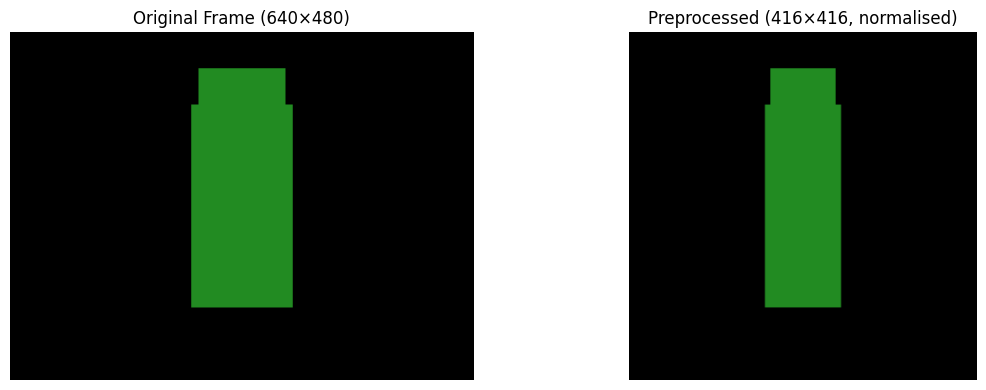

✅ Preprocessing verified


In [9]:
import sys
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

import numpy as np
import cv2
import matplotlib.pyplot as plt
from preprocessing import preprocess_frame, augment_image, draw_bounding_boxes

# Create a synthetic test frame (green gradient – simulating a bottle shape)
test_frame = np.zeros((480, 640, 3), dtype=np.uint8)
test_frame[100:380, 250:390] = [34, 139, 34]   # green rectangle = bottle region
test_frame[50:100, 260:380]  = [34, 139, 34]   # cap

# Preprocess
processed = preprocess_frame(test_frame)
print(f'Input  shape: {test_frame.shape}  dtype: {test_frame.dtype}')
print(f'Output shape: {processed.shape}  dtype: {processed.dtype}')
print(f'Value range : [{processed.min():.3f}, {processed.max():.3f}]')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(cv2.cvtColor(test_frame, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original Frame (640×480)', fontsize=12)
axes[0].axis('off')
axes[1].imshow(processed)
axes[1].set_title('Preprocessed (416×416, normalised)', fontsize=12)
axes[1].axis('off')
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'outputs' / 'preprocessing_demo.png', dpi=100)
plt.show()
print('✅ Preprocessing verified')

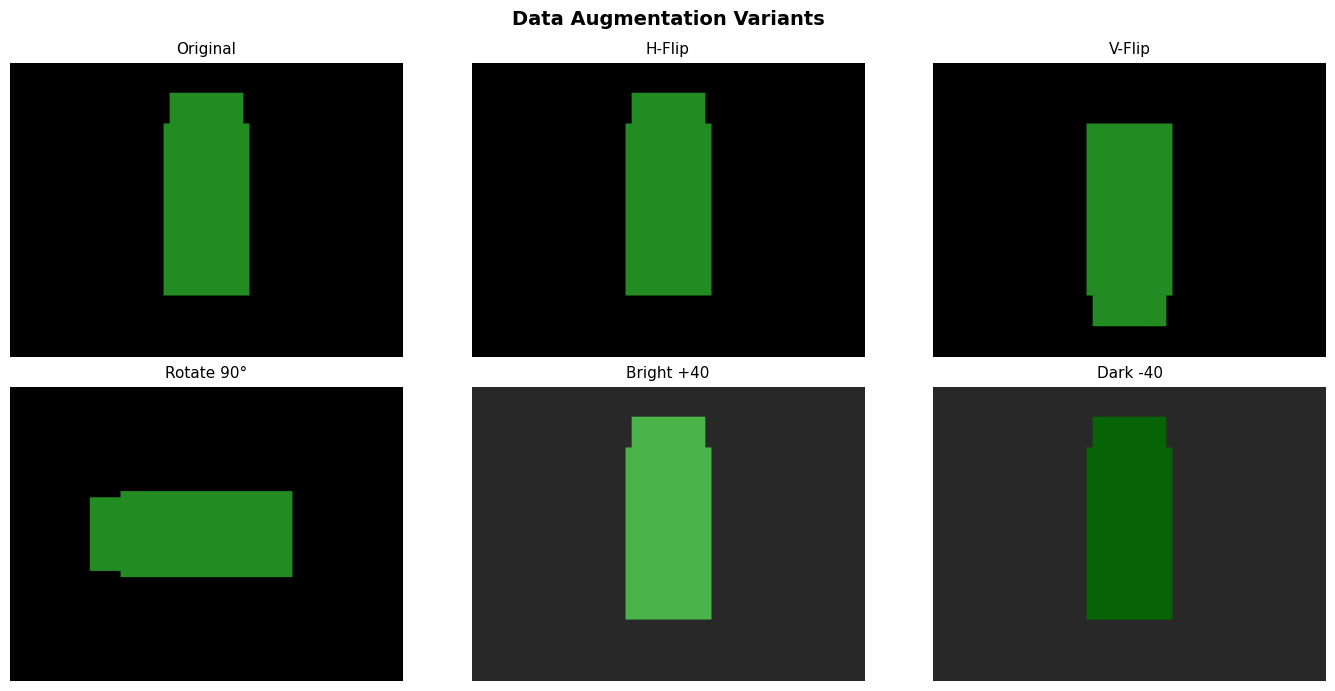

✅ 6 augmentation variants generated


In [10]:
import cv2

# Visualise all 6 augmentation variants
variants = augment_image(test_frame)
labels   = ['Original', 'H-Flip', 'V-Flip', 'Rotate 90°', 'Bright +40', 'Dark -40']

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
fig.suptitle('Data Augmentation Variants', fontsize=14, fontweight='bold')

for ax, img, lbl in zip(axes.flat, variants, labels):
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(lbl, fontsize=11)
    ax.axis('off')

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'outputs' / 'augmentation_demo.png', dpi=100)
plt.show()
print('✅ 6 augmentation variants generated')

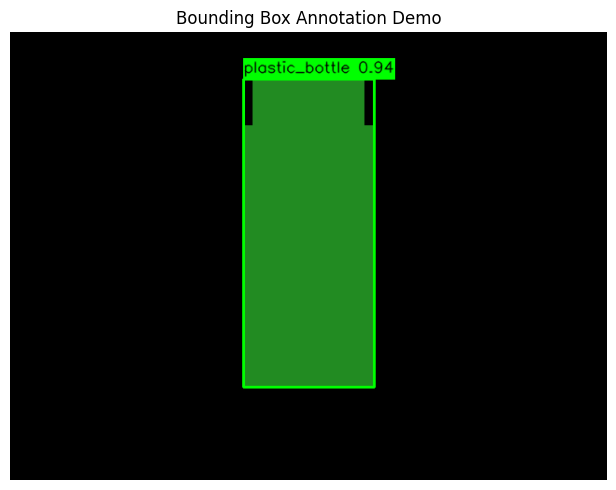

✅ Bounding box annotation verified


In [7]:
# Demonstrate bounding box drawing
sample_detections = [
    {'x1': 250, 'y1': 50,  'x2': 390, 'y2': 380, 'confidence': 0.94, 'label': 'plastic_bottle'}
]

annotated = draw_bounding_boxes(test_frame, sample_detections)

plt.figure(figsize=(7, 5))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.title('Bounding Box Annotation Demo', fontsize=12)
plt.axis('off')
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'outputs' / 'bbox_demo.png', dpi=100)
plt.show()
print('✅ Bounding box annotation verified')

---
## ✅ Notebook 1 Complete

**What was done:**
- Installed all dependencies
- Created the `plastisort/` project folder structure
- Wrote `src/preprocessing.py` to disk
- Verified: resize to 416×416, normalization to [0,1], 6 augmentations, bounding box drawing

**Next:** Open `02_detector_and_controller.ipynb`